🔷 Initial Dataset Shape: (520, 17)

🔷 Missing Values BEFORE adding NaN:
Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

🔷 Missing Values AFTER adding NaN:
Age                   26
Gender                16
Polyuria              16
Polydipsia            16
sudden weight loss    16
weakness              16
Polyphagia            16
Genital thrush        16
visual blurring       16
Itching               16
Irritability          16
delayed healing       16
partial paresis       16
muscle stiffness      16
Alopecia              16
Obesity               16
class                 16
dtype: int64

🔷 Sample rows containing NaN:
  

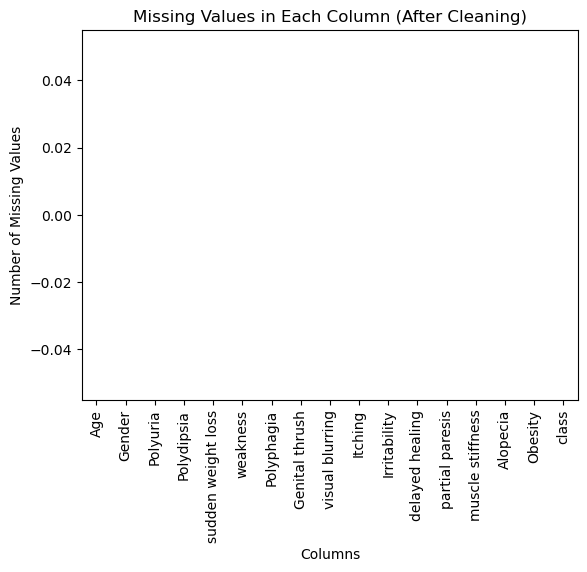

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# STEP 1: LOAD DATASET
# -------------------------------
df = pd.read_csv("diabetes_data_upload.csv")

print("🔷 Initial Dataset Shape:", df.shape)

# -------------------------------
# STEP 2: CHECK BEFORE ADDING NaN
# -------------------------------
print("\n🔷 Missing Values BEFORE adding NaN:")
print(df.isnull().sum())

# -------------------------------
# STEP 3: ADD NaN VALUES (5% in Age)
# -------------------------------
df.loc[df.sample(frac=0.05, random_state=42).index, 'Age'] = np.nan
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df.loc[df.sample(frac=0.03).index, col] = np.nan

print("\n🔷 Missing Values AFTER adding NaN:")
print(df.isnull().sum())

# -------------------------------
# STEP 4: SHOW ROWS WITH NaN
# -------------------------------
print("\n🔷 Sample rows containing NaN:")
print(df[df.isnull().any(axis=1)].head())

# -------------------------------
# STEP 5: STORE COUNT BEFORE FILLING
# -------------------------------
missing_before = df.isnull().sum().sum()
print("\n🔷 Total Missing Values BEFORE filling:", missing_before)

# -------------------------------
# STEP 6: FILL NaN VALUES (SIMPLE METHOD)
# -------------------------------

# Fill numerical column (Age) with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Fill categorical columns with mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])

# -------------------------------
# STEP 7: VERIFY AFTER FILLING
# -------------------------------
print("\n🔷 Missing Values AFTER filling:")
print(df.isnull().sum())

missing_after = df.isnull().sum().sum()
print("\n🔷 Total Missing Values AFTER filling:", missing_after)
print(df)

# -------------------------------
# STEP 8: VISUALIZE MISSING VALUES
# -------------------------------
plt.figure()
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values in Each Column (After Cleaning)")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.show()


In [10]:
df1=df.copy()
# Convert Yes/No to 1/0 for analysis
for col in df1.columns:
    if df1[col].dtype == 'object' and col not in ['Gender', 'class']:
        df1[col] = df1[col].map({'Yes':1, 'No':0})
       
df1['class'] = df1['class'].map({'Positive':1, 'Negative':0})
df1['Gender'] = df1['Gender'].map({'Male':1, 'Female':0})

# -------------------------------
# STATISTICAL MEASURES
# -------------------------------

print("\n🔷 COUNT:\n", df1.count())

print("\n🔷 SUM:\n", df1.sum())

print("\n🔷 MIN:\n", df1.min())

print("\n🔷 MAX:\n", df1.max())

print("\n🔷 MEAN:\n", df1.mean())

print("\n🔷 MEDIAN:\n", df1.median())

print("\n🔷 MODE:\n", df1.mode())

print("\n🔷 VARIANCE:\n", df1.var())

print("\n🔷 STANDARD DEVIATION:\n", df1.std())

# -------------------------------
# RANGE = MAX - MIN
# -------------------------------
print("\n🔷 RANGE:\n", df1.max() - df1.min())



🔷 COUNT:
 Age                   520
Gender                520
Polyuria              520
Polydipsia            520
sudden weight loss    520
weakness              520
Polyphagia            520
Genital thrush        520
visual blurring       520
Itching               520
Irritability          520
delayed healing       520
partial paresis       520
muscle stiffness      520
Alopecia              520
Obesity               520
class                 520
dtype: int64

🔷 SUM:
 Age                   24982.105263
Gender                  333.000000
Polyuria                250.000000
Polydipsia              229.000000
sudden weight loss      211.000000
weakness                312.000000
Polyphagia              231.000000
Genital thrush          112.000000
visual blurring         228.000000
Itching                 246.000000
Irritability            125.000000
delayed healing         230.000000
partial paresis         217.000000
muscle stiffness        192.000000
Alopecia                171.000000


In [13]:
# -------------------------------
# Q3 (PART 2): UNIQUE VALUES & COUNTS
# -------------------------------

print("\n\n🔷 Q3 PART 2: UNIQUE VALUES AND COUNTS\n")

for col in df1.columns:
    print(f"\n🔶 Column: {col}")
    
    # Unique count
    print("Unique Count:", df1[col].nunique())
    
    # Unique values
    print("Unique Values:", df1[col].unique())
    
    # Value counts
    print("Value Counts:\n", df1[col].value_counts())




🔷 Q3 PART 2: UNIQUE VALUES AND COUNTS


🔶 Column: Age
Unique Count: 52
Unique Values: [40.         58.         41.         45.         60.         55.
 48.04251012 66.         67.         70.         38.         35.
 61.         54.         43.         62.         39.         48.
 32.         42.         52.         53.         37.         49.
 63.         30.         50.         46.         36.         51.
 59.         65.         25.         47.         28.         68.
 56.         31.         85.         90.         72.         69.
 79.         34.         57.         16.         44.         27.
 29.         26.         33.         64.        ]
Value Counts:
 Age
35.00000    29
48.00000    28
48.04251    26
43.00000    25
30.00000    24
40.00000    22
55.00000    22
47.00000    21
38.00000    20
53.00000    19
50.00000    18
54.00000    16
39.00000    16
58.00000    16
45.00000    15
60.00000    14
57.00000    12
68.00000    10
66.00000     9
28.00000     8
46.00000     8
67.00000

Text(0, 0.5, 'Frequency')

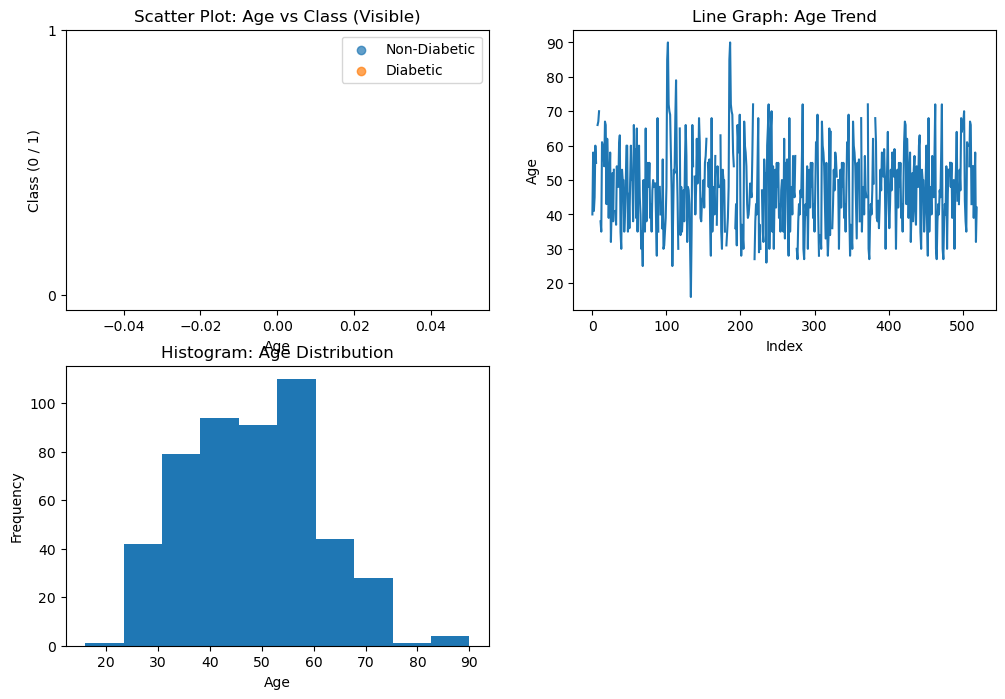

In [21]:
import matplotlib.pyplot as plt

# -------------------------------
# Q4: VISUALIZATION USING SUBPLOTS
# -------------------------------

plt.figure(figsize=(12,8))

# 🔶 1. SCATTER PLOT (Age vs Class)
plt.subplot(2,2,1)

# Separate classes
class0 = df1[df1['class'] == 0]
class1 = df1[df1['class'] == 1]

# Add vertical shift (KEY FIX)
plt.scatter(class0['Age'], np.zeros(len(class0)) + 0.1, label='Non-Diabetic', alpha=0.7)
plt.scatter(class1['Age'], np.ones(len(class1)) - 0.1, label='Diabetic', alpha=0.7)

plt.title("Scatter Plot: Age vs Class (Visible)")
plt.xlabel("Age")
plt.ylabel("Class (0 / 1)")
plt.yticks([0,1])
plt.legend()

# 🔶 2. LINE GRAPH (Age Trend)
plt.subplot(2,2,2)
plt.plot(df1['Age'])
plt.title("Line Graph: Age Trend")
plt.xlabel("Index")
plt.ylabel("Age")

# 🔶 3. HISTOGRAM (Age Distribution)
plt.subplot(2,2,3)
plt.hist(df1['Age'])
plt.title("Histogram: Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")




In [14]:
print("\n\n🔷 Q5: KNN MODEL RESULTS\n")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
pd.set_option('future.no_silent_downcasting', True)

# Load fresh dataset
df2 = pd.read_csv("diabetes_data_upload.csv")

# Clean spaces ONLY
df2 = df2.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

# Encode categorical safely using replace
for col in df2.columns:
    if df2[col].dtype == 'object' and col != 'class':
        df2[col] = df2[col].replace({'Yes':1, 'No':0})
        
# Encode Gender separately
df2['Gender'] = df2['Gender'].replace({'Male':1, 'Female':0})

# Encode target
df2['class'] = df2['class'].replace({'Positive':1, 'Negative':0})

# 🔥 FINAL FIX
df2['class'] = pd.to_numeric(df2['class'], errors='coerce')
df2 = df2.dropna(subset=['class'])
df2['class'] = df2['class'].astype(int)

# 🔥 DO NOT DROP ALL ROWS
# Just check:
print("Shape after encoding:", df2.shape)

# Split features and target
X = df2.drop('class', axis=1)
y = df2['class']

# 🔥 SCALE (now safe)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train model
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))





🔷 Q5: KNN MODEL RESULTS

Shape after encoding: (520, 17)
Accuracy: 0.9326923076923077
Precision: 0.9830508474576272
Recall: 0.90625
F1 Score: 0.943089430894309
